In [2]:
import pandas as pd
import numpy as np
import joblib, os, sys

from sklearn.ensemble         import RandomForestClassifier, VotingClassifier, IsolationForest
from sklearn.linear_model     import LogisticRegression
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.pipeline         import Pipeline

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 6)

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


In [3]:
df = pd.read_csv('../ml-backend/data/features_dataset.csv')

print(f"Shape dataset  : {df.shape}")
print(f"Jumlah fitur   : {df.shape[1] - 1}")
print(f"\nDistribusi label:")
label_map = {0: 'Aman', 1: 'Phishing', 2: 'Judi Online'}
for label, nama in label_map.items():
    count  = (df['label'] == label).sum()
    persen = count / len(df) * 100
    print(f"  {nama:<12}: {count} ({persen:.1f}%)")

print(f"\nAda nilai kosong?: {df.isnull().sum().sum()}")

Shape dataset  : (15000, 28)
Jumlah fitur   : 27

Distribusi label:
  Aman        : 5000 (33.3%)
  Phishing    : 5000 (33.3%)
  Judi Online : 5000 (33.3%)

Ada nilai kosong?: 0


In [5]:
FEATURE_COLUMNS = [
    'url_length', 'has_https', 'dot_count', 'hyphen_count',
    'at_count', 'double_slash', 'digit_count', 'domain_length',
    'path_depth', 'has_query', 'has_suspicious_tld', 'has_ip',
    'has_phishing_keyword', 'has_gambling_keyword', 'has_brand_spoofing',
    'subdomain_length', 'subdomain_count', 'domain_entropy',
    'special_chars', 'path_length', 'digit_ratio_url', 'has_port', 
    'has_redirect', 'consonant_ratio', 'query_length', 'query_params', 
    'has_fragment'
]

print(f"Fitur yang digunakan: {len(FEATURE_COLUMNS)}")
print(f"Fitur: {FEATURE_COLUMNS}")

X = df[FEATURE_COLUMNS]
y = df['label']

print(f"\nShape X (fitur): {X.shape}")
print(f"Shape y (label): {y.shape}")

Fitur yang digunakan: 27
Fitur: ['url_length', 'has_https', 'dot_count', 'hyphen_count', 'at_count', 'double_slash', 'digit_count', 'domain_length', 'path_depth', 'has_query', 'has_suspicious_tld', 'has_ip', 'has_phishing_keyword', 'has_gambling_keyword', 'has_brand_spoofing', 'subdomain_length', 'subdomain_count', 'domain_entropy', 'special_chars', 'path_length', 'digit_ratio_url', 'has_port', 'has_redirect', 'consonant_ratio', 'query_length', 'query_params', 'has_fragment']

Shape X (fitur): (15000, 27)
Shape y (label): (15000,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    stratify     = y,
    random_state = 42
)

print(f"Data training : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Data testing  : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nDistribusi label di training set:")
for label, nama in label_map.items():
    count = (y_train == label).sum()
    print(f"  {nama}: {count}")

Data training : 12000 baris (80%)
Data testing  : 3000 baris (20%)

Distribusi label di training set:
  Aman: 4000
  Phishing: 4000
  Judi Online: 4000


In [7]:
print("Melatih Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators      = 150,
    max_depth         = 20,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred, average='weighted')

print(f"\n✅ Random Forest selesai!")
print(f"   Accuracy : {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print(f"   F1-Score : {rf_f1:.4f}")

Melatih Random Forest...

✅ Random Forest selesai!
   Accuracy : 0.9860 (98.60%)
   F1-Score : 0.9860


In [8]:
print("Melatih Logistic Regression...")

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter     = 1000,
        C            = 1.0,
        class_weight = 'balanced',
        random_state = 42,
        n_jobs       = -1
    ))
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred, average='weighted')

print(f"\n✅ Logistic Regression selesai!")
print(f"   Accuracy : {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print(f"   F1-Score : {lr_f1:.4f}")

Melatih Logistic Regression...

✅ Logistic Regression selesai!
   Accuracy : 0.9533 (95.33%)
   F1-Score : 0.9533


c:\Dev\project\web\NETRA\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [9]:
print("Membuat Hybrid Ensemble Model...")

hybrid_model = VotingClassifier(
    estimators = [
        ('random_forest', rf_model),
        ('logistic_reg',  lr_pipeline)
    ],
    voting  = 'soft',
    weights = [2, 1]
)

hybrid_model.fit(X_train, y_train)
hybrid_pred = hybrid_model.predict(X_test)
hybrid_acc  = accuracy_score(y_test, hybrid_pred)
hybrid_f1   = f1_score(y_test, hybrid_pred, average='weighted')

print(f"\n✅ Hybrid Model selesai!")
print(f"   Accuracy : {hybrid_acc:.4f} ({hybrid_acc*100:.2f}%)")
print(f"   F1-Score : {hybrid_f1:.4f}")

Membuat Hybrid Ensemble Model...

✅ Hybrid Model selesai!
   Accuracy : 0.9787 (97.87%)
   F1-Score : 0.9787


c:\Dev\project\web\NETRA\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [10]:
label_names = ['Aman (0)', 'Phishing (1)', 'Judi Online (2)']

print("=== LAPORAN DETAIL HYBRID MODEL ===\n")
report = classification_report(y_test, hybrid_pred, target_names=label_names, output_dict=True)
print(classification_report(y_test, hybrid_pred, target_names=label_names))

print("\n── Interpretasi ────────────────────────────────────")
for nama, key in zip(label_names, ['Aman (0)', 'Phishing (1)', 'Judi Online (2)']):
    p = report[key]['precision']
    r = report[key]['recall']
    f = report[key]['f1-score']
    masalah = []
    if p < 0.80: masalah.append(f"Precision rendah ({p:.2f}) → banyak false positive")
    if r < 0.80: masalah.append(f"Recall rendah ({r:.2f}) → banyak yang terlewat")
    status = "⚠️  " + " | ".join(masalah) if masalah else "✅ Baik"
    print(f"{nama}: {status}")

=== LAPORAN DETAIL HYBRID MODEL ===

                 precision    recall  f1-score   support

       Aman (0)       0.98      0.98      0.98      1000
   Phishing (1)       0.98      0.97      0.98      1000
Judi Online (2)       0.98      0.98      0.98      1000

       accuracy                           0.98      3000
      macro avg       0.98      0.98      0.98      3000
   weighted avg       0.98      0.98      0.98      3000


── Interpretasi ────────────────────────────────────
Aman (0): ✅ Baik
Phishing (1): ✅ Baik
Judi Online (2): ✅ Baik


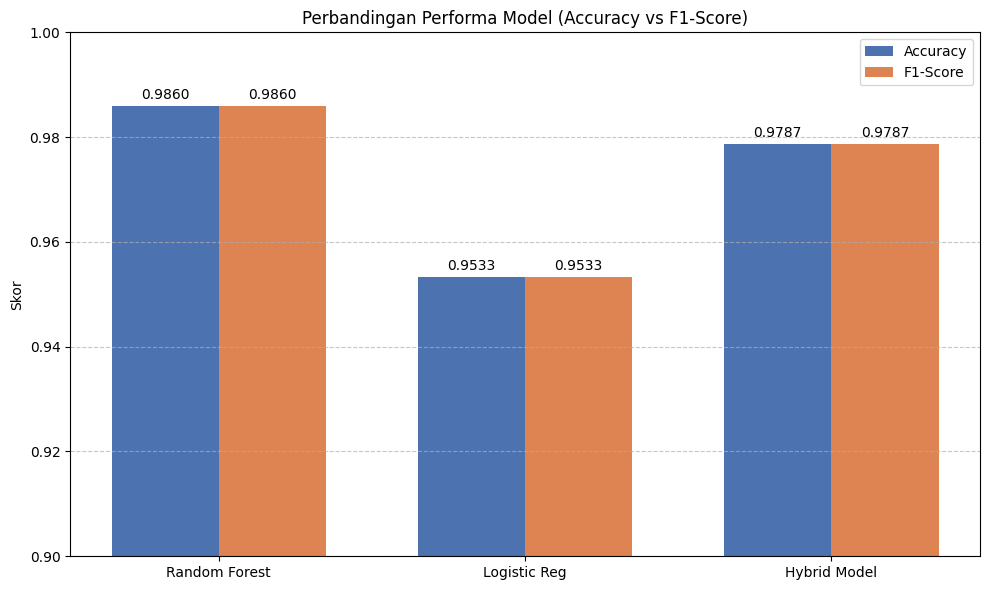

In [11]:
import numpy as np

models = ['Random Forest', 'Logistic Reg', 'Hybrid Model']
accuracies = [rf_acc, lr_acc, hybrid_acc]
f1_scores = [rf_f1, lr_f1, hybrid_f1]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#4C72B0')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='#DD8452')

ax.set_ylabel('Skor')
ax.set_title('Perbandingan Performa Model (Accuracy vs F1-Score)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim([0.90, 1.0])
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../dataset/model_comparison.png', dpi=100)
plt.show()

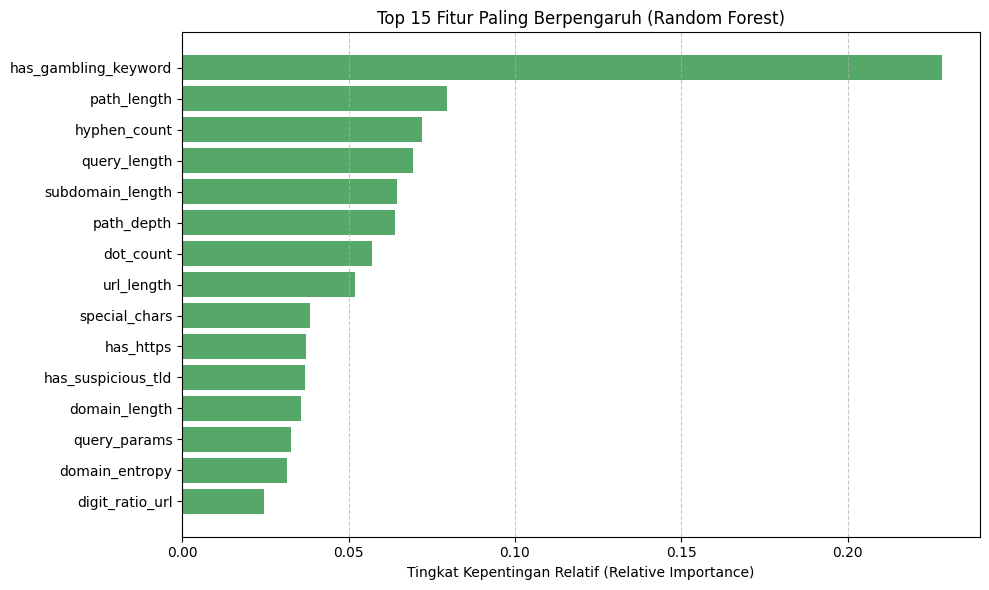

Interpretasi:
Fitur di posisi paling atas adalah penyumbang terbesar dalam keputusan model
untuk mengklasifikasikan URL sebagai Aman, Phishing, atau Judi Online.


In [12]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1] 

top_n = 15
top_indices = indices[:top_n]
top_features = [FEATURE_COLUMNS[i] for i in top_indices]
top_importances = importances[top_indices]

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), top_importances[::-1], color='#55A868', align='center')
plt.yticks(range(top_n), top_features[::-1])
plt.xlabel('Tingkat Kepentingan Relatif (Relative Importance)')
plt.title(f'Top {top_n} Fitur Paling Berpengaruh (Random Forest)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../dataset/feature_importance.png', dpi=100)
plt.show()

print("Interpretasi:")
print("Fitur di posisi paling atas adalah penyumbang terbesar dalam keputusan model")
print("untuk mengklasifikasikan URL sebagai Aman, Phishing, atau Judi Online.")

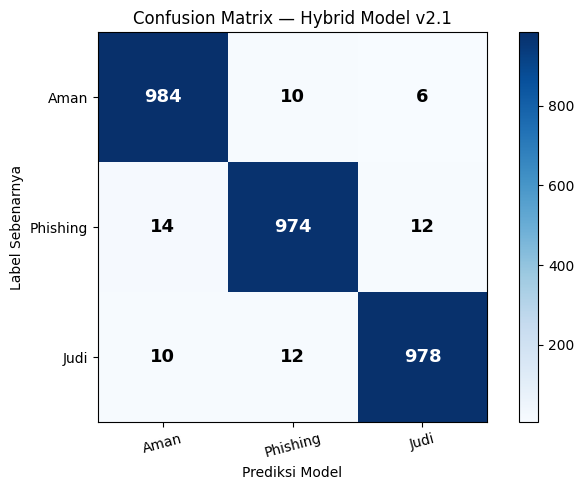

Diagonal utama = prediksi benar.
Nilai di luar diagonal = kesalahan prediksi.


In [13]:
cm = confusion_matrix(y_test, hybrid_pred)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(['Aman', 'Phishing', 'Judi'], rotation=15)
ax.set_yticklabels(['Aman', 'Phishing', 'Judi'])
ax.set_xlabel('Prediksi Model')
ax.set_ylabel('Label Sebenarnya')
ax.set_title('Confusion Matrix — Hybrid Model v2.1')

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=13, fontweight='bold')

plt.colorbar(im)
plt.tight_layout()
plt.savefig('../dataset/confusion_matrix_v21.png', dpi=100)
plt.show()

print("Diagonal utama = prediksi benar.")
print("Nilai di luar diagonal = kesalahan prediksi.")

In [14]:
os.makedirs('../ml-backend/models', exist_ok=True)

joblib.dump(rf_model,        '../ml-backend/models/random_forest.pkl')
joblib.dump(lr_pipeline,     '../ml-backend/models/logistic_regression.pkl')
joblib.dump(hybrid_model,    '../ml-backend/models/hybrid_model.pkl')
joblib.dump(FEATURE_COLUMNS, '../ml-backend/models/feature_columns.pkl')

print("✅ Model supervised disimpan!")
for f in os.listdir('../ml-backend/models'):
    size = os.path.getsize(f'../ml-backend/models/{f}') / 1024
    print(f"  {f:<40} {size:.1f} KB")

✅ Model supervised disimpan!
  feature_columns.pkl                      0.4 KB
  hybrid_model.pkl                         13841.5 KB
  isolation_forest.pkl                     2044.8 KB
  logistic_regression.pkl                  3.3 KB
  random_forest.pkl                        6918.1 KB
  scaler_isolation.pkl                     1.8 KB


In [15]:
print("Melatih Isolation Forest v2.1 (dari SEMUA data)...")

X_semua = df[FEATURE_COLUMNS]
y_semua = df['label']

scaler_if     = StandardScaler()
X_semua_scaled = scaler_if.fit_transform(X_semua)

iso_forest = IsolationForest(
    n_estimators  = 200,
    # contamination: perkiraan proporsi data anomali di dataset
    # 0.15 = ~15% data dianggap anomali — lebih realistis dari 0.05
    contamination = 0.15,
    max_samples   = 'auto',
    max_features  = 1.0,
    random_state  = 42,
    n_jobs        = -1
)

iso_forest.fit(X_semua_scaled)

print("✅ Isolation Forest v2.1 selesai dilatih!")
print(f"   Dilatih dari: {len(X_semua_scaled)} URL (semua kategori)")
print(f"   Jumlah pohon: {iso_forest.n_estimators}")
print(f"   Contamination: {iso_forest.contamination}")

Melatih Isolation Forest v2.1 (dari SEMUA data)...
✅ Isolation Forest v2.1 selesai dilatih!
   Dilatih dari: 15000 URL (semua kategori)
   Jumlah pohon: 200
   Contamination: 0.15


In [16]:
# Evaluasi Isolation Forest
prediksi_if  = iso_forest.predict(X_semua_scaled)
skor_anomali = iso_forest.score_samples(X_semua_scaled)
is_anomali   = (prediksi_if == -1).astype(int)

print("═" * 55)
print("Hasil Deteksi Isolation Forest v2.1 per Kategori")
print("═" * 55)

for label, nama in [(0, 'Aman'), (1, 'Phishing'), (2, 'Judi Online')]:
    mask       = y_semua == label
    total      = mask.sum()
    terdeteksi = is_anomali[mask].sum()
    persen     = terdeteksi / total * 100
    skor_rata  = skor_anomali[mask].mean()
    bar = '█' * int(persen / 5)
    print(f"\n{nama} (total: {total})")
    print(f"  Terdeteksi anomali: {terdeteksi}/{total} ({persen:.1f}%)")
    print(f"  Rata-rata skor    : {skor_rata:.4f}")
    print(f"  {bar}")

print("\n─" * 55)
print("Target ideal:")
print("  URL Aman      → < 20% terdeteksi anomali")
print("  URL Phishing  → > 50% terdeteksi anomali")
print("  URL Judi      → > 50% terdeteksi anomali")

═══════════════════════════════════════════════════════
Hasil Deteksi Isolation Forest v2.1 per Kategori
═══════════════════════════════════════════════════════

Aman (total: 5000)
  Terdeteksi anomali: 245/5000 (4.9%)
  Rata-rata skor    : -0.4046
  

Phishing (total: 5000)
  Terdeteksi anomali: 1189/5000 (23.8%)
  Rata-rata skor    : -0.4352
  ████

Judi Online (total: 5000)
  Terdeteksi anomali: 816/5000 (16.3%)
  Rata-rata skor    : -0.4489
  ███

─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
Target ideal:
  URL Aman      → < 20% terdeteksi anomali
  URL Phishing  → > 50% terdeteksi anomali
  URL Judi      → > 50% terdeteksi anomali


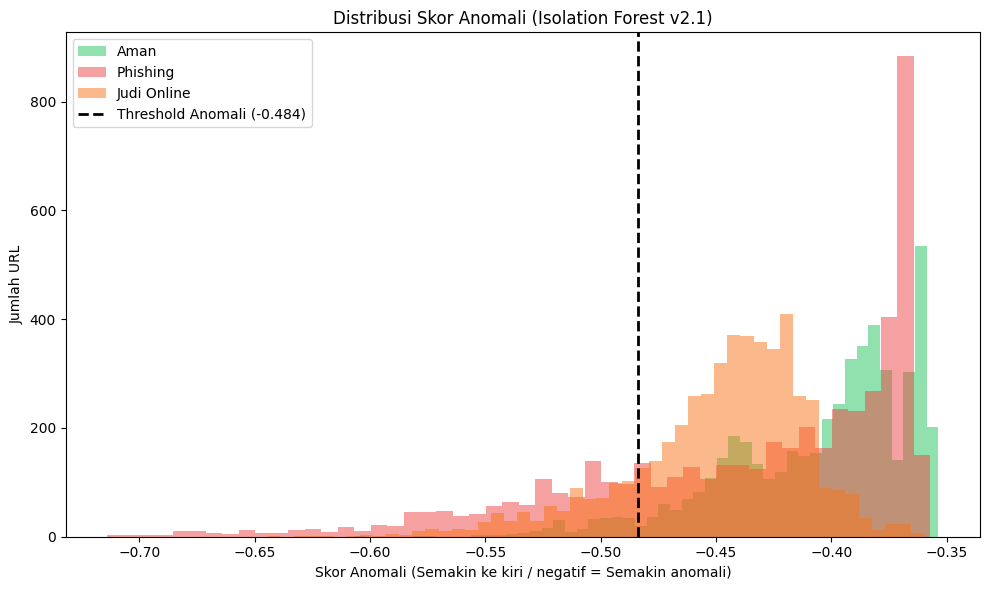

Interpretasi:
Data di sebelah KIRI garis putus-putus diklasifikasikan sebagai ANOMALI (-1).
Idealnya, gunung grafik 'Aman' berada di KANAN garis, dan grafik berbahaya di KIRI garis.


In [18]:
plt.figure(figsize=(10, 6))

skor_aman = skor_anomali[y_semua == 0]
skor_phish = skor_anomali[y_semua == 1]
skor_judi = skor_anomali[y_semua == 2]

plt.hist(skor_aman, bins=50, alpha=0.5, label='Aman', color='#22c55e')
plt.hist(skor_phish, bins=50, alpha=0.5, label='Phishing', color='#ef4444')
plt.hist(skor_judi, bins=50, alpha=0.5, label='Judi Online', color='#f97316')

plt.axvline(x=iso_forest.offset_, color='black', linestyle='--', linewidth=2, 
            label=f'Threshold Anomali ({iso_forest.offset_:.3f})')

plt.title('Distribusi Skor Anomali (Isolation Forest v2.1)')
plt.xlabel('Skor Anomali (Semakin ke kiri / negatif = Semakin anomali)')
plt.ylabel('Jumlah URL')
plt.legend()
plt.tight_layout()
plt.savefig('../dataset/anomaly_distribution.png', dpi=100)
plt.show()

print("Interpretasi:")
print("Data di sebelah KIRI garis putus-putus diklasifikasikan sebagai ANOMALI (-1).")
print("Idealnya, gunung grafik 'Aman' berada di KANAN garis, dan grafik berbahaya di KIRI garis.")

In [19]:
joblib.dump(iso_forest, '../ml-backend/models/isolation_forest.pkl')
joblib.dump(scaler_if,  '../ml-backend/models/scaler_isolation.pkl')

print("✅ Model Isolation Forest v2.1 disimpan!")
for f in ['isolation_forest.pkl', 'scaler_isolation.pkl']:
    path = f'../ml-backend/models/{f}'
    size = os.path.getsize(path) / 1024
    print(f"  {f}: {size:.1f} KB")

print("\n🎉 Semua model berhasil diperbarui! Restart server Flask untuk menerapkan.")

✅ Model Isolation Forest v2.1 disimpan!
  isolation_forest.pkl: 2044.8 KB
  scaler_isolation.pkl: 1.8 KB

🎉 Semua model berhasil diperbarui! Restart server Flask untuk menerapkan.
